# Goal

Use duplicate observations to quantify repeatability/scatter in key HAPY measurements and identify catastrophic disagreements.

In [301]:
from pathlib import Path
import numpy as np
from astropy.table import Table

from hapy.utils.results_table import prepare_analysis_table
from hapy.utils import plotting

import os
homedir = os.getenv("HOME")

tels = ['INT','BOK','HDI','MOS']

import warnings
warnings.filterwarnings("ignore")

In [139]:
from astropy.stats import sigma_clip
import numpy as np

def clipped_std(x, sigma=3.0, maxiters=5):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)

    if np.sum(good) == 0:
        return np.nan

    clipped = sigma_clip(x[good], sigma=sigma, maxiters=maxiters)
    return np.nanstd(clipped.data[~clipped.mask])

In [140]:
working_dir = os.path.join(homedir,'research/Virgo/hapypost')
os.chdir(working_dir)

In [219]:
mergedtab = os.path.join(working_dir,'tables/merged_results_virgo_20260514.fits')
%run ~/github/hapypost/hapypost/validate_duplicates.py $mergedtab --scheme virgo

Read 782 rows from /Users/rfinn/research/Virgo/hapypost/tables/merged_results_virgo_20260514.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 65, 'low': 283, 'medium': 434}
ELL_MISMATCH 235
FILTER_WARNING 75
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 281
length of table after applying CLEAN flag = 706
Observation multiplicity (N_obs : N_galaxies)
1: 468
2: 92
3: 18
Found 146 duplicate pairs


# Test Plots

In [5]:
for c in tab.colnames:
    if 'CSGR' in c:
        print(c)

CSGR_SEC
CSGR_EXISTS
CSGR_FITS
CSGR_PHOT_OK
CSGR_HAPY_MORPH_OK
CSGR_HAPY_MORPH_FLAG
CSGR_SKYSTD_ADU
CSGR_SKYMED_ADU
CSGR_SKYSTD_PHYS
CSGR_M20
CSGR_ASYM
CSGR_ASYM_ERR
CSGR_SCALE_ADU_CGS
CSGR_HAPY_NPIX
CSGR_HAPY_FILLFRAC
CSGR_HAPY_SNP_ALL
CSGR_HAPY_SNP_DET
CSGR_GINI_THRESHOLD
CSGR_HAPY_GINI
CSGR_HAPY_M20
CSGR_HAPY_ASYM
CSGR_HAPY_ASYM_ERR
CSGR_HAPY_MTOT
CSGR_HAPY_M20SUM
CSGR_HAPY_FLUX_SEG
CSGR_HAPY_MTOT2
CSGR_HAPY_RMOM_ARCSEC
CSGR_CONTSCL
CSGR_R_PROFILE_OK
CSGR_R_PROFILE_NGOOD
CSGR_R_PROFILE_MASKFRAC_MAX
CSGR_R25_ARCSEC
CSGR_R25_PIX
CSGR_R50_ARCSEC
CSGR_R50_PIX
CSGR_R75_ARCSEC
CSGR_R75_PIX
CSGR_R24_ARCSEC
CSGR_R24_ARCSEC_ERR
CSGR_R24_MAG
CSGR_R24_MAG_ERR
CSGR_R25_ISO_ARCSEC
CSGR_R25_ISO_ARCSEC_ERR
CSGR_R25_ISO_MAG
CSGR_R25_ISO_MAG_ERR
CSGR_R25P5_ARCSEC
CSGR_R25P5_ARCSEC_ERR
CSGR_R25P5_MAG
CSGR_R25P5_MAG_ERR
CSGR_R24_VEGA_ARCSEC
CSGR_R24_VEGA_ARCSEC_ERR
CSGR_R24_VEGA_MAG
CSGR_R24_VEGA_MAG_ERR
CSGR_R25_VEGA_ARCSEC
CSGR_R25_VEGA_ARCSEC_ERR
CSGR_R25_VEGA_MAG
CSGR_R25_VEGA_MAG_ERR
CSGR_R30R24_

  VFID       R24_FLUX_CGS    
-------- --------------------
VFID6126 1.20076446146668e-10
  VFID        R24_FLUX_CGS     
-------- ----------------------
VFID6126 1.4634780515796597e-10

number of input = 103


UFuncTypeError: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.StrDType'> -> None

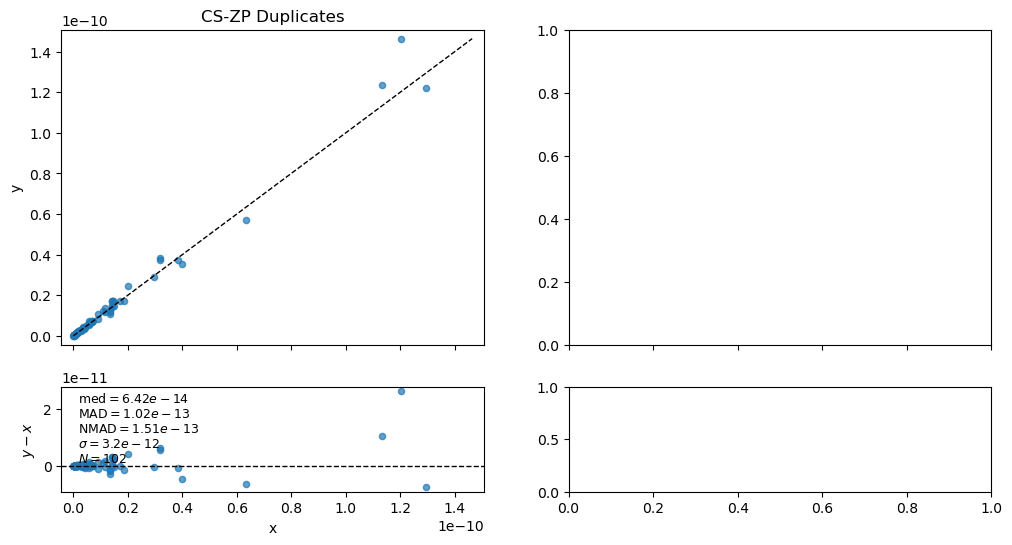

In [18]:
col1 = "H_TOT_FLUX_CGS"
col2 = "CSGR_H_TOT_FLUX_CGS"

col1 = "R24_FLUX_CGS"
col2 = "CSGR_R24_FLUX_CGS"

#col1 = "H_HAPY_FLUX_SEG"
#col2 = "CSGR_HAPY_FLUX_SEG"

for t in tels[0]:
    flag = pairtab
    x1 = tab[col1][pairtab['idx1']]
    y1 = tab[col1][pairtab['idx2']]
    
    x2 = tab[col2][pairtab['idx1']]
    y2 = tab[col2][pairtab['idx2']]
    
    res1 = y1 - x1
    res2 = y2 - x2
    std1 = np.nanstd(res1)
    std2 = np.nanstd(res2)
    
    # print outliers
    tindices = np.arange(len(x1))
    out1 = tindices[np.abs(res1)/std1 > 5]
    out2 = tindices[np.abs(res2)/std2 > 5]
    #print(out1)
    for i in out1:
        m1 = tab['VFID',col1][pairtab['idx1']][i]
        m2 = tab['VFID',col1][pairtab['idx2']][i]
        print(m1)
        print(m2)
        print()
        #print(pairtab[i])
        #print(x1[i], y1[i])
    
    logit = True
    logit = False
    if logit:
        x1 = np.log10(x1)
        y1 = np.log10(y1)
        x2 = np.log10(x2)
        y2 = np.log10(y2)
    print(f"number of input = {len(x1)}")
    plot_with_residuals(x1, y1, x2=x2, y2=y2, outfile="test.png", title1="CS-ZP Duplicates", title2="CS-gr Duplicates")

INT
CS-ZP: median res = -0.0257000000000005,0.079
CS-gr: median res = -0.0257000000000005,0.079

INT CS-ZP OUTLIERS 
  VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2140       BOK 13.4147   VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2140       HDI 13.1412


  VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2544       HDI 12.0928   VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2544       INT 11.7798


  VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID6386       INT 18.3935   VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID6386       MOS 18.0418


  VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID6447       INT  16.906   VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID6447       MOS  16.553


####################
INT CS-gr OUTLIERS
  VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2140       BOK 13.4147   VFID   TELESCOPE GAL_MAG
-------- --------- -------
VFID2140       HDI 13.1412


  VFID   TELESCOPE GAL_

UFuncTypeError: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.StrDType'> -> None

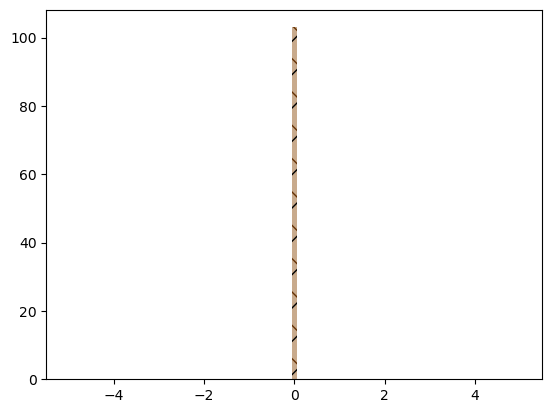

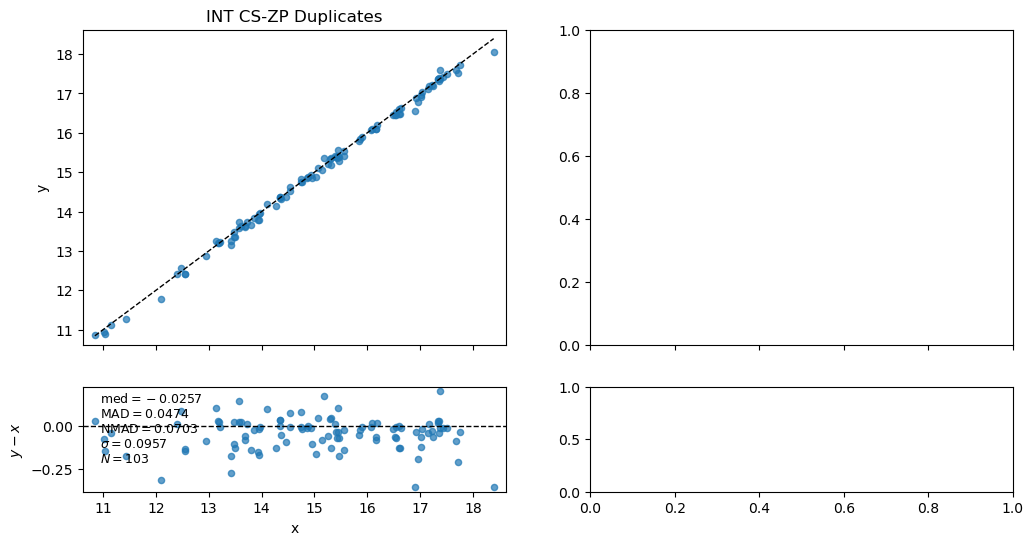

In [17]:
col1 = "H_TOT_FLUX_CGS"
col2 = "CSGR_H_TOT_FLUX_CGS"

col1 = "R24_FLUX_CGS"
col2 = "CSGR_R24_FLUX_CGS"

col1 = "GAL_MAG"
col2 = "GAL_MAG"

#col1 = "H_PETRO_FLUX"
#col2 = "CSGR_H_PETRO_FLUX"

for t in [tels[0]]:
    print(t)
    #flag = (pairtab['TEL1'] == t) & (pairtab['TEL2'] == t) 
    flag = np.ones(len(pairtab),'bool')
    x1 = tab[col1][pairtab['idx1'][flag]]
    y1 = tab[col1][pairtab['idx2'][flag]]
    
    x2 = tab[col2][pairtab['idx1'][flag]]
    y2 = tab[col2][pairtab['idx2'][flag]]

    #print(x1)
    #print(y1)
    res1 = y1 - x1
    res2 = y2 - x2
    std1 = np.nanstd(res1)
    std2 = np.nanstd(res2)
    std1 = clipped_std(res1)
    std2 = clipped_std(res2)
    # percent diff
    pd1 = res1/x1#np.mean([x1, y1])
    pd2 = res2/x2#np.mean([x2, y2])
    #print(np.nanmedian(pd1))
    plt.figure()
    mybins = np.linspace(-5,5,100)
    plt.hist(pd1,label="CS-ZP",bins=mybins,alpha=.4,hatch='\\')
    plt.hist(pd2,label="CS-gr",bins=mybins,alpha=.4,hatch='/')
    
    
    print(f"CS-ZP: median res = {np.nanmedian(res1)},{std1:.3f}")
    print(f"CS-gr: median res = {np.nanmedian(res2)},{std2:.3f}")
    print()
    # print outliers
    tindices = np.arange(len(x1))
    out1 = tindices[np.abs(res1)/std1 > 3]
    out2 = tindices[np.abs(res2)/std2 > 3]
    #print(out1)
    print(t+" CS-ZP OUTLIERS ")
    for i in out1:
        m1 = tab['VFID','TELESCOPE',col1][pairtab['idx1']][i]
        m2 = tab['VFID','TELESCOPE',col1][pairtab['idx2']][i]
        print(m1,m2)
        print()
        print()
        #print(pairtab[i])
        #print(x1[i], y1[i])
    
    print("####################")
    print(t+" CS-gr OUTLIERS")
    for i in out2:
        m1 = tab['VFID','TELESCOPE',col1][pairtab['idx1']][i]
        m2 = tab['VFID','TELESCOPE',col1][pairtab['idx2']][i]
        print(m1,m2)
        print()
        print()
        #print(pairtab[i])
        #print(x1[i], y1[i])
    
    logit = True
    logit = False
    if logit:
        x1 = np.log10(x1)
        y1 = np.log10(y1)
        x2 = np.log10(x2)
        y2 = np.log10(y2)
    print(f"number of input = {len(x1)}")
    plot_with_residuals(x1, y1, x2=x2, y2=y2, outfile="test.png", title1=t+" CS-ZP Duplicates", title2=t+" CS-gr Duplicates")


# Applying Filter Correction Cut to HAPY

In [307]:
%run ~/github/hapypost/hapypost/validate_duplicates.py $mergedtab --scheme virgo --apply-filter-cut  --max-ha-filter-correction 1.1
tab_fc = tab.copy()
pairs_fc = pairtab.copy()

Read 782 rows from /Users/rfinn/research/Virgo/hapypost/tables/merged_results_virgo_20260514.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 65, 'low': 283, 'medium': 434}
ELL_MISMATCH 235
FILTER_WARNING 75
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 281
length of table after applying CLEAN flag = 606
Observation multiplicity (N_obs : N_galaxies)
1: 436
2: 67
3: 12
Found 103 duplicate pairs


In [308]:
dup_summary1_fc = make_stats_table(tab_fc, pairs_fc, METRICS)
dup_summary1_fc = dup_summary1_fc[display_cols]


dup_summary2_fc = make_stats_table(tab_fc, pairs_fc, MORPH_METRICS)
dup_summary2_fc = dup_summary2_fc[display_cols]

dup_summary_fc = make_stats_table(tab_fc, pairs_fc, ALL_METRICS)
dup_summary_fc = dup_summary_fc[display_cols]

In [309]:
subset=[]
for c in display_cols:
    if ("NMAD" in c) | ("med" in c):
        subset.append(c)
dup_summary1_fc[display_cols].sort_values("NMAD_overall").style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,NMAD_INT-INT,N_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,NMAD_INT-MOS
16,R25_ARCSEC,dex,103,0.0004,0.0167,10,0.0071,5,0.0061,5,0.0086,9,0.0148,34,0.0143,3,0.0213,23,0.0263,13,0.0381
17,R50_ARCSEC,dex,103,0.0006,0.0181,10,0.0074,5,0.0111,5,0.0115,9,0.0101,34,0.0121,3,0.0052,23,0.0291,13,0.0246
18,R75_ARCSEC,dex,103,-0.0023,0.0200,10,0.0111,5,0.0110,5,0.0115,9,0.0109,34,0.0174,3,0.0421,23,0.0291,13,0.0192
2,R24_FLUX_CGS,dex,102,0.0318,0.0491,10,0.0132,4,0.0062,5,0.0173,9,0.0052,34,0.0302,3,0.0183,23,0.0274,13,0.0325
8,CSGR_H_ISO17E18_ARCSEC,dex,67,-0.0023,0.0576,6,0.0257,5,0.1527,4,0.0434,9,0.0500,25,0.0449,3,0.1523,7,0.0244,8,0.0884
9,H_ISO5E17_ARCSEC,dex,58,-0.0181,0.0584,5,0.1046,5,0.0644,4,0.0581,9,0.0530,22,0.0441,2,0.0715,6,0.0225,5,0.0856
19,H25_ARCSEC,dex,59,-0.0060,0.0608,5,0.0202,5,0.1150,4,0.1362,9,0.0413,22,0.0739,2,0.8260,6,0.0454,6,0.1365
7,H_ISO17E18_ARCSEC,dex,59,-0.0084,0.0653,5,0.0289,5,0.0243,4,0.0221,9,0.0700,22,0.0583,2,0.0734,6,0.0540,6,0.0952
0,GAL_MAG,mag,103,-0.0257,0.0703,10,0.0234,5,0.0216,5,0.0408,9,0.0863,34,0.0796,3,0.1868,23,0.0681,13,0.0694
10,CSGR_H_ISO5E17_ARCSEC,dex,66,-0.0099,0.0782,6,0.0118,5,0.0361,4,0.0402,9,0.0660,25,0.0637,3,0.0100,7,0.0776,7,0.0949


In [310]:
subset=[]
for c in display_cols:
    if ("NMAD" in c) | ("med" in c):
        subset.append(c)
dup_summary2_fc[display_cols].sort_values("NMAD_overall").style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,NMAD_INT-INT,N_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,NMAD_INT-MOS
17,R_C30,value,102,-0.0011,0.0110,10,0.0066,4,0.0017,5,0.0046,9,0.0036,34,0.0118,3,0.0173,23,0.0078,13,0.0111
20,R_SM_GINI,value,75,0.0014,0.0115,10,0.0061,5,0.0037,5,0.0100,9,0.0126,28,0.0108,2,0.0425,8,0.0253,8,0.0146
4,CSGR_HAPY_GINI,value,98,0.0008,0.0210,10,0.0077,5,0.0124,5,0.0514,9,0.0197,31,0.0415,3,0.0493,22,0.0074,12,0.0200
28,R_SM_S,value,75,-0.0113,0.0229,10,0.0052,5,0.0110,5,0.0995,9,0.0157,28,0.0256,2,0.4174,8,0.0151,8,0.0909
3,H_HAPY_GINI,value,89,0.0073,0.0282,10,0.0064,5,0.0174,5,0.0611,9,0.0370,29,0.0608,3,0.0462,16,0.0125,11,0.0106
2,R_HAPY_ASYM,value,103,-0.0008,0.0301,10,0.0077,5,0.0369,5,0.0164,9,0.0243,34,0.0466,3,0.0340,23,0.0158,13,0.0215
11,H_HAPY_FILLFRAC,value,103,-0.0072,0.0328,10,0.0121,5,0.0684,5,0.1084,9,0.0602,34,0.0676,3,0.1025,23,0.0086,13,0.0101
12,CSGR_HAPY_FILLFRAC,value,103,-0.0011,0.0331,10,0.0059,5,0.0100,5,0.0896,9,0.0602,34,0.0499,3,0.0380,23,0.0068,13,0.0349
22,R_SM_M20,value,75,-0.0022,0.0462,10,0.0522,5,0.0304,5,0.0817,9,0.0433,28,0.0332,2,0.0569,8,0.0473,8,0.0270
29,H_SM_S,value,75,-0.0060,0.0488,10,0.0419,5,0.0535,5,0.0630,9,0.0533,28,0.0442,2,0.3484,8,0.0148,8,0.0368


In [311]:
10.**.05-1

0.12201845430196334

# Stats Tables

In [312]:
mergedtab = os.path.join(working_dir,'tables/merged_results_virgo_20260514.fits')
%run ~/github/hapypost/hapypost/validate_duplicates.py $mergedtab --scheme virgo

Read 782 rows from /Users/rfinn/research/Virgo/hapypost/tables/merged_results_virgo_20260514.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 65, 'low': 283, 'medium': 434}
ELL_MISMATCH 235
FILTER_WARNING 75
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 281
length of table after applying CLEAN flag = 706
Observation multiplicity (N_obs : N_galaxies)
1: 468
2: 92
3: 18
Found 146 duplicate pairs


In [313]:
pairs = pairtab.copy()


def make_stats_table(tab, pairs, METRICS):
    import numpy as np
    import pandas as pd
    

    # ------------------------------------------------------------
    # Duplicate validation summary table
    # Assumes:
    #   tab   = prepared merged_results table
    #   pairs = duplicate pair table with idx1, idx2, TEL1, TEL2, same_tel
    # ------------------------------------------------------------
    
    
    
    PAIR_GROUPS = {
        "overall": None,
        "BOK-BOK": ("BOK", "BOK"),
        "INT-INT": ("INT", "INT"),
        "HDI-HDI": ("HDI", "HDI"),
        "BOK-INT": ("BOK", "INT"),
        "BOK-HDI": ("BOK", "HDI"),
        "INT-HDI": ("INT", "HDI"),
        "BOK-MOS": ("BOK", "MOS"),
        "INT-MOS": ("INT", "MOS"),
    }
    
    
    def nmad(x):
        x = np.asarray(x, dtype=float)
        good = np.isfinite(x)
        if np.sum(good) == 0:
            return np.nan
        med = np.nanmedian(x[good])
        mad = np.nanmedian(np.abs(x[good] - med))
        return 1.4826 * mad
    
    
    def get_pair_residuals(tab, pairs, metric, mode="diff"):
        i1 = np.asarray(pairs["idx1"], dtype=int)
        i2 = np.asarray(pairs["idx2"], dtype=int)
    
        x1 = np.asarray(tab[metric][i1], dtype=float)
        x2 = np.asarray(tab[metric][i2], dtype=float)
    
        good = np.isfinite(x1) & np.isfinite(x2)
    
        if mode == "diff":
            res = np.full(len(pairs), np.nan)
            res[good] = x2[good] - x1[good]
    
        elif mode == "logratio":
            good &= (x1 > 0) & (x2 > 0)
            res = np.full(len(pairs), np.nan)
            res[good] = np.log10(x2[good] / x1[good])
    
        else:
            raise ValueError(f"Unknown mode: {mode}")
    
        return res
    
    
    def pair_group_mask(pairs, group):
        if group is None:
            return np.ones(len(pairs), dtype=bool)
    
        tel_a, tel_b = group
        tel1 = np.asarray(pairs["TEL1"]).astype(str)
        tel2 = np.asarray(pairs["TEL2"]).astype(str)
    
        return ((tel1 == tel_a) & (tel2 == tel_b)) | ((tel1 == tel_b) & (tel2 == tel_a))
    
    
    rows = []
    
    for metric, mode in METRICS:
        if metric not in tab.colnames:
            continue
    
        res = get_pair_residuals(tab, pairs, metric, mode=mode)
    
        row = {
            "parameter": metric,
            "units": "mag" if mode == "diff" and "MAG" in metric else ("dex" if mode == "logratio" else "value"),
        }
    
        for group_name, group_def in PAIR_GROUPS.items():
            m = pair_group_mask(pairs, group_def)
            vals = res[m]
            good = np.isfinite(vals)
    
            row[f"N_{group_name}"] = int(np.sum(good))
            row[f"med_{group_name}"] = np.nanmedian(vals[good]) if np.any(good) else np.nan
            row[f"NMAD_{group_name}"] = nmad(vals)
    
        rows.append(row)
    
    dup_summary = pd.DataFrame(rows)
    

    
    return dup_summary
METRICS = [
    # name, residual mode
    ("GAL_MAG", "diff"),              # mag
    ("R24_MAG", "diff"),              # mag
    ("R24_FLUX_CGS", "logratio"),   # dex
    ("H_R24_FLUX_CGS", "logratio"),   # dex
    ("CSGR_H_R24_FLUX_CGS", "logratio"),   # dex
    ("H_TOT_FLUX_CGS", "logratio"),   # dex
    ("CSGR_H_TOT_FLUX_CGS", "logratio"),   # dex
    ("H_ISO17E18_ARCSEC", "logratio"),   # dex
    ("CSGR_H_ISO17E18_ARCSEC", "logratio"),   # dex
    ("H_ISO5E17_ARCSEC", "logratio"),   # dex
    ("CSGR_H_ISO5E17_ARCSEC", "logratio"),   # dex
    ("H_ISO17E18_FLUX_CGS", "logratio"),   # dex
    ("CSGR_H_ISO17E18_FLUX_CGS", "logratio"),   # dex
    ("H_ISO5E17_FLUX_CGS", "logratio"),   # dex
    ("CSGR_H_ISO5E17_FLUX_CGS", "logratio"),   # dex
    ("CSGR_SKYSTD_PHYS", "logratio"),   # dex
    ("R25_ARCSEC", "logratio"),       # dex
    ("R50_ARCSEC", "logratio"),       # dex
    ("R75_ARCSEC", "logratio"),       # dex
    ("H25_ARCSEC", "logratio"),       # dex
    ("H50_ARCSEC", "logratio"),       # dex
    ("H75_ARCSEC", "logratio"),       # dex
    ("CSGR_H25_ARCSEC", "logratio"),       # dex
    ("CSGR_H50_ARCSEC", "logratio"),       # dex
    ("CSGR_H75_ARCSEC", "logratio"),       # dex
    ("H_MAXDET_ARCSEC", "logratio"),  # dex
]
MORPH_METRICS = [
    ("R_HAPY_GINI", "diff"),
    ("R_HAPY_M20", "diff"),
    ("R_HAPY_ASYM", "diff"),
    ("H_HAPY_GINI", "diff"),
    ("CSGR_HAPY_GINI", "diff"),
    ("H_HAPY_M20", "diff"),
    ("CSGR_HAPY_M20", "diff"),
    ("H_HAPY_RMOM_ARCSEC", "diff"),
    ("CSGR_HAPY_RMOM_ARCSEC", "diff"),
    ("H_HAPY_ASYM", "diff"),
    ("CSGR_HAPY_ASYM", "diff"),
    ("H_HAPY_FILLFRAC", "diff"),
    ("CSGR_HAPY_FILLFRAC", "diff"),
    ("H_HAPY_SNP_DET", "diff"),
    ("CSGR_HAPY_SNP_DET", "diff"),
    ("DELTA_GINI", "diff"),
    ("DELTA_M20", "diff"),
    ("R_C30", "diff"),
    ("H_C30_R24", "diff"),
    ("CSGR_H_C30_R24", "diff"),
    ("R_SM_GINI", "diff"),
    ("H_SM_GINI", "diff"),
    ("R_SM_M20", "diff"),
    ("H_SM_M20", "diff"),
    ("R_SM_ASYM", "diff"),
    ("H_SM_ASYM", "diff"),
    ("R_SM_C", "diff"),
    ("H_SM_C", "diff"),
    ("R_SM_A", "diff"),
    ("H_SM_A", "diff"),
    ("R_SM_S", "diff"),
    ("H_SM_S", "diff"),
]

ALL_METRICS = METRICS + MORPH_METRICS
# Display compact version
display_cols = [
    "parameter", "units",
    "N_overall", "med_overall", "NMAD_overall",
    "N_BOK-BOK", "NMAD_BOK-BOK",
    "N_INT-INT", "NMAD_INT-INT",
    "N_HDI-HDI", "NMAD_HDI-HDI",
    "N_BOK-INT", "NMAD_BOK-INT",
    "N_BOK-HDI", "NMAD_BOK-HDI",
    "N_INT-HDI", "NMAD_INT-HDI",
    "N_BOK-MOS", "NMAD_BOK-MOS",
    "N_INT-MOS", "NMAD_INT-MOS",
]


In [314]:

dup_summary1 = make_stats_table(tab, pairs, METRICS)
dup_summary1 = dup_summary1[display_cols]


dup_summary2 = make_stats_table(tab, pairs, MORPH_METRICS)
dup_summary2 = dup_summary2[display_cols]

dup_summary = make_stats_table(tab, pairs, ALL_METRICS)
dup_summary = dup_summary[display_cols]

In [315]:
subset=[]
for c in display_cols:
    if ("NMAD" in c) | ("med" in c):
        subset.append(c)
dup_summary1[display_cols].sort_values("NMAD_overall").style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,NMAD_INT-INT,N_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,NMAD_INT-MOS
16,R25_ARCSEC,dex,146,0.0005,0.0165,10,0.0071,11,0.0109,5,0.0086,29,0.0159,34,0.0143,14,0.0309,24,0.0262,18,0.0351
17,R50_ARCSEC,dex,146,0.0005,0.0174,10,0.0074,11,0.0109,5,0.0115,29,0.0101,34,0.0121,14,0.0267,24,0.0275,18,0.0337
18,R75_ARCSEC,dex,146,-0.0025,0.0181,10,0.0111,11,0.0151,5,0.0115,29,0.0102,34,0.0174,14,0.0253,24,0.0254,18,0.0369
2,R24_FLUX_CGS,dex,144,0.0107,0.0728,10,0.0132,10,0.0056,5,0.0173,29,0.0103,34,0.0302,13,0.0323,24,0.0268,18,0.0303
7,H_ISO17E18_ARCSEC,dex,91,0.0066,0.0751,5,0.0289,10,0.0705,4,0.0221,25,0.0866,22,0.0583,9,0.1841,7,0.0250,9,0.2317
1,R24_MAG,mag,144,-0.0115,0.0803,10,0.0329,10,0.0139,5,0.0434,29,0.0258,34,0.0756,13,0.0807,24,0.0669,18,0.0758
8,CSGR_H_ISO17E18_ARCSEC,dex,100,0.0044,0.0819,6,0.0257,10,0.1032,4,0.0434,25,0.1357,25,0.0449,10,0.1111,8,0.0382,12,0.0798
9,H_ISO5E17_ARCSEC,dex,90,-0.0087,0.0826,5,0.1046,10,0.1146,4,0.0581,24,0.1316,22,0.0441,10,0.1076,7,0.0234,8,0.4397
0,GAL_MAG,mag,146,-0.0120,0.0830,10,0.0234,11,0.0362,5,0.0408,29,0.0726,34,0.0796,14,0.1634,24,0.0737,18,0.1062
10,CSGR_H_ISO5E17_ARCSEC,dex,99,-0.0056,0.0894,6,0.0118,10,0.0601,4,0.0402,24,0.1999,25,0.0637,11,0.0817,8,0.0507,11,0.1940


In [316]:
subset=[]
for c in display_cols:
    if ("NMAD" in c) | ("med" in c):
        subset.append(c)
dup_summary2[display_cols].sort_values("NMAD_overall").style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,NMAD_INT-INT,N_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,NMAD_INT-MOS
20,R_SM_GINI,value,114,0.0011,0.0117,10,0.0061,11,0.0070,5,0.0100,28,0.0143,28,0.0108,12,0.0072,9,0.0313,11,0.0225
17,R_C30,value,144,-0.0024,0.0119,10,0.0066,10,0.0087,5,0.0046,29,0.0101,34,0.0118,13,0.0200,24,0.0076,18,0.0130
4,CSGR_HAPY_GINI,value,140,0.0026,0.0215,10,0.0077,11,0.0164,5,0.0514,28,0.0248,31,0.0415,14,0.0260,23,0.0089,17,0.0305
28,R_SM_S,value,114,-0.0087,0.0266,10,0.0052,11,0.0136,5,0.0995,28,0.0186,28,0.0256,12,0.0697,9,0.0135,11,0.0665
2,R_HAPY_ASYM,value,146,-0.0009,0.0305,10,0.0077,11,0.0220,5,0.0164,29,0.0254,34,0.0466,14,0.0484,24,0.0166,18,0.0180
12,CSGR_HAPY_FILLFRAC,value,146,-0.0022,0.0331,10,0.0059,11,0.0129,5,0.0896,29,0.0507,34,0.0499,14,0.0399,24,0.0098,18,0.0510
3,H_HAPY_GINI,value,129,0.0035,0.0342,10,0.0064,11,0.0338,5,0.0611,28,0.0370,29,0.0608,13,0.0482,17,0.0128,15,0.0468
11,H_HAPY_FILLFRAC,value,146,-0.0050,0.0370,10,0.0121,11,0.0219,5,0.1084,29,0.0544,34,0.0676,14,0.0512,24,0.0090,18,0.0248
22,R_SM_M20,value,114,-0.0024,0.0499,10,0.0522,11,0.0304,5,0.0817,28,0.0546,28,0.0332,12,0.0853,9,0.0488,11,0.0424
21,H_SM_GINI,value,114,-0.0060,0.0543,10,0.0198,11,0.0323,5,0.0916,28,0.0673,28,0.0489,12,0.0577,9,0.0977,11,0.0773


# Summary Table for Paper

In [317]:
import numpy as np
import pandas as pd

PAPER_DUP_METRICS = [
    ("R25_ARCSEC", "dex", r"$R_{25}(r)$"),
    ("R50_ARCSEC", "dex", r"$R_{50}(r)$"),
    ("R75_ARCSEC", "dex", r"$R_{75}(r)$"),
    ("R24_FLUX_CGS", "dex", r"$F_{R_{24}}(r)$"),
    ("R_C30", "value", r"$C_{30}(r)$"),

    ("H50_ARCSEC", "dex", r"$R_{50}(\mathrm{H}\alpha)$"),
    ("H75_ARCSEC", "dex", r"$R_{75}(\mathrm{H}\alpha)$"),
    ("CSGR_H_R24_FLUX_CGS", "dex", r"$F_{R_{24}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO17E18_ARCSEC", "dex", r"$R_{\mathrm{iso}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO17E18_FLUX_CGS", "dex", r"$F_{\mathrm{iso}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO5E17_ARCSEC", "dex", r"$R_{\mathrm{iso17E18}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO5E17_FLUX_CGS", "dex", r"$F_{\mathrm{iso5E17}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_C30_R24", "value", r"$C_{30}(\mathrm{H}\alpha)$"),
]

PAPER_DUP_METRICS_R = [
    ("R25_ARCSEC", "dex", r"$R_{25}(r)$"),
    ("R50_ARCSEC", "dex", r"$R_{50}(r)$"),
    ("R75_ARCSEC", "dex", r"$R_{75}(r)$"),
    ("R24_FLUX_CGS", "dex", r"$F_{R_{24}}(r)$"),
    ("R_C30", "value", r"$C_{30}(r)$"),
]


PAPER_DUP_METRICS_H = [
    ("CSGR_H25_ARCSEC", "dex", r"$R_{25}(\mathrm{H}\alpha)$"),
    ("CSGR_H50_ARCSEC", "dex", r"$R_{50}(\mathrm{H}\alpha)$"),
    ("CSGR_H75_ARCSEC", "dex", r"$R_{75}(\mathrm{H}\alpha)$"),        
    ("CSGR_H_ISO17E18_ARCSEC", "dex", r"$R_{\mathrm{17E18}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO5E17_ARCSEC", "dex", r"$R_{\mathrm{5E18}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_R24_FLUX_CGS", "dex", r"$F_{R_{24}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO17E18_FLUX_CGS", "dex", r"$F_{\mathrm{17E18}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_ISO5E17_FLUX_CGS", "dex", r"$F_{\mathrm{5E17}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_C30_R24", "value", r"$C_{30}(\mathrm{H}\alpha)$"),
]


def make_paper_duplicate_table(df_summary, metrics=PAPER_DUP_METRICS):
    rows = []

    for col, unit, label in metrics:
        if col not in set(df_summary["parameter"]):
            print(f"WARNING: missing {col}")
            continue

        r = df_summary[df_summary["parameter"] == col].iloc[0]

        rows.append({
            "Quantity": label,
            "Unit": unit,
            r"$N_{\rm pair}$": int(r["N_overall"]),
            r"Median offset": r["med_overall"],
            r"Overall NMAD": r["NMAD_overall"],
            r"BOK$-$BOK NMAD": r.get("NMAD_BOK-BOK", np.nan),
            r"INT$-$INT NMAD": r.get("NMAD_INT-INT", np.nan),
            r"HDI$-$HDI NMAD": r.get("NMAD_HDI-HDI", np.nan),
            r"Cross-inst. NMAD": np.nanmedian([
                r.get("NMAD_BOK-INT", np.nan),
                r.get("NMAD_BOK-HDI", np.nan),
                r.get("NMAD_INT-HDI", np.nan),
                r.get("NMAD_BOK-MOS", np.nan),
                r.get("NMAD_INT-MOS", np.nan),
            ]),
        })

    return pd.DataFrame(rows)

def make_paper_duplicate_table(df_summary, metrics=PAPER_DUP_METRICS):
    import numpy as np
    import pandas as pd

    rows = []

    for col, unit, label in metrics:
        if col not in set(df_summary["parameter"]):
            print(f"WARNING: missing {col}")
            continue

        r = df_summary[df_summary["parameter"] == col].iloc[0]

        cross_n_cols = ["N_BOK-INT", "N_BOK-HDI", "N_INT-HDI", "N_BOK-MOS", "N_INT-MOS"]
        cross_nmad_cols = ["NMAD_BOK-INT", "NMAD_BOK-HDI", "NMAD_INT-HDI", "NMAD_BOK-MOS", "NMAD_INT-MOS"]

        cross_ns = np.array([r.get(c, 0) for c in cross_n_cols], dtype=float)
        cross_nmads = np.array([r.get(c, np.nan) for c in cross_nmad_cols], dtype=float)

        good_cross = np.isfinite(cross_nmads) & (cross_ns > 0)
        n_cross = int(np.nansum(cross_ns[good_cross]))
        nmad_cross = np.nanmedian(cross_nmads[good_cross]) if np.any(good_cross) else np.nan

        rows.append({
            "Quantity": label,
            "Unit": unit,
            r"$N_{\rm all}$": int(r.get("N_overall", 0)),
            "Med. offset": r.get("med_overall", np.nan),
            r"NMAD$_{\rm all}$": r.get("NMAD_overall", np.nan),

            r"$N_{\rm BOK}$": int(r.get("N_BOK-BOK", 0)),
            r"NMAD$_{\rm BOK}$": r.get("NMAD_BOK-BOK", np.nan),

            r"$N_{\rm INT}$": int(r.get("N_INT-INT", 0)),
            r"NMAD$_{\rm INT}$": r.get("NMAD_INT-INT", np.nan),

            r"$N_{\rm HDI}$": int(r.get("N_HDI-HDI", 0)),
            r"NMAD$_{\rm HDI}$": r.get("NMAD_HDI-HDI", np.nan),

            r"$N_{\rm cross}$": n_cross,
            r"NMAD$_{\rm cross}$": nmad_cross,
        })

    return pd.DataFrame(rows)


def paper_dup_to_latex(paper_dup, caption=None, label="tab:duplicate_validation"):
    import numpy as np

    df = paper_dup.copy()

    for c in df.columns:
        if ("NMAD" in c) or ("offset" in c) or ("Median" in c):
            df[c] = df[c].map(lambda x: f"{x:.3f}" if np.isfinite(x) else r"\nodata")

    latex = df.to_latex(
        index=False,
        escape=False,
        header=False,
    )

    lines = latex.splitlines()

    body = []
    for line in lines:
        if line.startswith(r"\begin{tabular}"):
            continue
        if line.startswith(r"\toprule") or line.startswith(r"\midrule") or line.startswith(r"\bottomrule"):
            continue
        if line.startswith(r"\end{tabular}"):
            continue
        body.append(line)

    custom_header = [
        r"\begin{table*}",
        r"\centering",
        r"\caption{" + (caption or "Duplicate-observation validation statistics for selected HAPY measurements.") + r"}",
        rf"\label{{{label}}}",
        r"\begin{tabular}{lcccccccccccc}",
        r"\hline",
        r"Quantity & Unit & $\rm N_{\rm all}$ & Med. & Overall & $\rm N_{BOK}$ & BOK$-$BOK & $\rm N_{\rm INT}$ & INT$-$INT & $\rm N_{\rm HDI}$ & HDI$-$HDI & $\rm N_{\rm cross}$ & Cross-inst. \\",
        r"         &      &                & offset & NMAD    &               & NMAD     &               & NMAD     &               & NMAD     &                 & NMAD        \\",
        r"\hline",
    ]

    custom_footer = [
        r"\hline",
        r"\end{tabular}",
        r"\tablecomments{NMAD values are computed from pairwise duplicate residuals. "
        r"The overall column includes all duplicate pairs. "
        r"Same-instrument columns use only BOK--BOK, INT--INT, and HDI--HDI pairs, respectively; there are no MOS--MOS pairs. "
        r"The cross-instrument column combines all mixed-instrument duplicate pairs. "
        r"The number of contributing pairs may differ by quantity because some measurements fail or are undefined.}",
        r"\end{table*}",
    ]

    return "\n".join(custom_header + body + custom_footer)

In [318]:
paper_dup = make_paper_duplicate_table(dup_summary,metrics=PAPER_DUP_METRICS_R)
paper_dup


,Quantity,Unit,$N_{\rm all}$,Med. offset,NMAD$_{\rm all}$,$N_{\rm BOK}$,NMAD$_{\rm BOK}$,$N_{\rm INT}$,NMAD$_{\rm INT}$,$N_{\rm HDI}$,NMAD$_{\rm HDI}$,$N_{\rm cross}$,NMAD$_{\rm cross}$
0,$R_{25}(r)$,dex,146,0.000518,0.016482,10,0.007062,11,0.010948,5,0.008611,119,0.026221
1,$R_{50}(r)$,dex,146,0.000485,0.017409,10,0.007377,11,0.010943,5,0.011546,119,0.026676
2,$R_{75}(r)$,dex,146,-0.002491,0.018110,10,0.011085,11,0.015136,5,0.011532,119,0.025296
3,$F_{R_{24}}(r)$,dex,144,0.010693,0.072847,10,0.013157,10,0.005579,5,0.017347,118,0.030236
4,$C_{30}(r)$,value,144,-0.002433,0.011925,10,0.006556,10,0.008686,5,0.004573,118,0.011831


In [319]:

paper_dup_fc = make_paper_duplicate_table(dup_summary_fc,metrics=PAPER_DUP_METRICS_H)
paper_dup_fc

,Quantity,Unit,$N_{\rm all}$,Med. offset,NMAD$_{\rm all}$,$N_{\rm BOK}$,NMAD$_{\rm BOK}$,$N_{\rm INT}$,NMAD$_{\rm INT}$,$N_{\rm HDI}$,NMAD$_{\rm HDI}$,$N_{\rm cross}$,NMAD$_{\rm cross}$
0,$R_{25}(\mathrm{H}\alpha)$,dex,67,-0.004465,0.095170,6,0.013763,5,0.114927,4,0.110825,52,0.091567
1,$R_{50}(\mathrm{H}\alpha)$,dex,67,-0.012544,0.091735,6,0.021669,5,0.050432,4,0.096685,52,0.059935
2,$R_{75}(\mathrm{H}\alpha)$,dex,67,-0.013918,0.160626,6,0.012127,5,0.423030,4,0.227352,52,0.364036
3,$R_{\mathrm{17E18}}(\mathrm{H}\alpha)$,dex,67,-0.002333,0.057619,6,0.025710,5,0.152703,4,0.043394,52,0.049966
4,$R_{\mathrm{5E18}}(\mathrm{H}\alpha)$,dex,66,-0.009924,0.078169,6,0.011751,5,0.036109,4,0.040205,51,0.065961
5,$F_{R_{24}}(\mathrm{H}\alpha)$,dex,66,-0.008489,0.108737,6,0.030476,4,0.099236,4,0.038635,52,0.080719
6,$F_{\mathrm{17E18}}(\mathrm{H}\alpha)$,dex,67,-0.007616,0.101091,6,0.049027,5,0.104381,4,0.021609,52,0.177819
7,$F_{\mathrm{5E17}}(\mathrm{H}\alpha)$,dex,66,-0.007376,0.114176,6,0.067703,5,0.058681,4,0.044523,51,0.115151
8,$C_{30}(\mathrm{H}\alpha)$,value,66,-0.007046,0.049772,6,0.025672,4,0.124533,4,0.084451,52,0.049242


In [324]:
latex = paper_dup_to_latex(
    paper_dup,
    caption=(
        "Duplicate-observation validation statistics for selected HAPY $r$-band measurements. "
        "Scatter values are reported as NMAD values in the units listed."
    ),
    label="tab:duplicate_validation_r",
)

print(latex)

\begin{table*}
\centering
\caption{Duplicate-observation validation statistics for selected HAPY $r$-band measurements. Scatter values are reported as NMAD values in the units listed.}
\label{tab:duplicate_validation_r}
\begin{tabular}{lcccccccccccc}
\hline
Quantity & Unit & $\rm N_{\rm all}$ & Med. & Overall & $\rm N_{BOK}$ & BOK$-$BOK & $\rm N_{\rm INT}$ & INT$-$INT & $\rm N_{\rm HDI}$ & HDI$-$HDI & $\rm N_{\rm cross}$ & Cross-inst. \\
         &      &                & offset & NMAD    &               & NMAD     &               & NMAD     &               & NMAD     &                 & NMAD        \\
\hline
$R_{25}(r)$ & dex & 146 & 0.001 & 0.016 & 10 & 0.007 & 11 & 0.011 & 5 & 0.009 & 119 & 0.026 \\
$R_{50}(r)$ & dex & 146 & 0.000 & 0.017 & 10 & 0.007 & 11 & 0.011 & 5 & 0.012 & 119 & 0.027 \\
$R_{75}(r)$ & dex & 146 & -0.002 & 0.018 & 10 & 0.011 & 11 & 0.015 & 5 & 0.012 & 119 & 0.025 \\
$F_{R_{24}}(r)$ & dex & 144 & 0.011 & 0.073 & 10 & 0.013 & 10 & 0.006 & 5 & 0.017 & 118 & 0.030 \

In [323]:
latex_fc = paper_dup_to_latex(
    paper_dup_fc,
    caption=(
        "Duplicate-observation validation statistics for selected HAPY \ha \ measurements. "
        "Scatter values are reported as NMAD values in the units listed."
    ),
    label="tab:duplicate_validation_h",
)

print(latex_fc)

\begin{table*}
\centering
\caption{Duplicate-observation validation statistics for selected HAPY measurements. Scatter values are reported as NMAD values in the units listed.}
\label{tab:duplicate_validation_h}
\begin{tabular}{lcccccccccccc}
\hline
Quantity & Unit & $\rm N_{\rm all}$ & Med. & Overall & $\rm N_{BOK}$ & BOK$-$BOK & $\rm N_{\rm INT}$ & INT$-$INT & $\rm N_{\rm HDI}$ & HDI$-$HDI & $\rm N_{\rm cross}$ & Cross-inst. \\
         &      &                & offset & NMAD    &               & NMAD     &               & NMAD     &               & NMAD     &                 & NMAD        \\
\hline
$R_{25}(\mathrm{H}\alpha)$ & dex & 67 & -0.004 & 0.095 & 6 & 0.014 & 5 & 0.115 & 4 & 0.111 & 52 & 0.092 \\
$R_{50}(\mathrm{H}\alpha)$ & dex & 67 & -0.013 & 0.092 & 6 & 0.022 & 5 & 0.050 & 4 & 0.097 & 52 & 0.060 \\
$R_{75}(\mathrm{H}\alpha)$ & dex & 67 & -0.014 & 0.161 & 6 & 0.012 & 5 & 0.423 & 4 & 0.227 & 52 & 0.364 \\
$R_{\mathrm{17E18}}(\mathrm{H}\alpha)$ & dex & 67 & -0.002 & 0.058 & 6 

In [272]:
10**.04-1

0.09647819614318509

# Comparing with Pre DEC 2025 Changes

In [34]:
from astropy.table import Table
import numpy as np


def build_legacy_pairs(d, tab=None):
    """
    Build duplicate-pair table from legacy duplicate indices.

    Parameters
    ----------
    d : object or dict-like
        Must have dupindex1, dupindex2, and preferably htab.
    tab : astropy.table.Table, optional
        Legacy measurement table. If None, uses d.htab.

    Returns
    -------
    pairs : astropy.table.Table
        Columns: idx1, idx2, VFID, TEL1, TEL2, same_tel
    """
    if tab is None:
        tab = d.htab

    idx1 = np.asarray(d.dupindex1, dtype=int)
    idx2 = np.asarray(d.dupindex2, dtype=int)

    if "TEL" not in tab.colnames:
        raise ValueError("Legacy table needs TEL column")

    tel = np.asarray(tab["TEL"]).astype(str)

    if "VFID" in tab.colnames:
        vfid = np.asarray(tab["VFID"]).astype(str)
    else:
        vfid = np.full(len(tab), "", dtype=str)

    tel1 = tel[idx1]
    tel2 = tel[idx2]
    same_tel = tel1 == tel2

    pairs = Table()
    pairs["idx1"] = idx1
    pairs["idx2"] = idx2
    pairs["VFID"] = vfid[idx1]
    pairs["TEL1"] = tel1
    pairs["TEL2"] = tel2
    pairs["same_tel"] = same_tel

    return pairs

In [35]:
%run ~/github/havirgo/python/duplicates.py

number of galaxies observed in halpha =  868
number after removing galaxies using bad flag from excel spreadsheet =  774
number of duplicate observations = 153


In [60]:
OLD_TO_NEW = {
    # photometry
    "GAL_MAG": "GAL_MAG",
    "M24": "R24_MAG",
    "HF_TOT": "H_TOT_FLUX_CGS",
    "HF_R24": "H_R24_FLUX_CGS",

    # sizes
    "R_F50": "R50_ARCSEC",
    "R_F75": "R75_ARCSEC",
    "HR_F50": "H50_ARCSEC",

    # concentration
    "C30": "R_C30",
    "HC30": "H_C30_R24",

    # ellipse morphology
    "ELLIP_GINI": "R_HAPY_GINI",
    "ELLIP_HGINI": "H_HAPY_GINI",
    "ELLIP_M20": "R_HAPY_M20",
    "ELLIP_HM20": "H_HAPY_M20",
    "ELLIP_ASYM": "R_HAPY_ASYM",
    "ELLIP_HASYM": "H_HAPY_ASYM",

    # statmorph
    "SMORPH_GINI": "R_SM_GINI",
    "SMORPH_HGINI": "H_SM_GINI",
    "SMORPH_M20": "R_SM_M20",
    "SMORPH_HM20": "H_SM_M20",
    "SMORPH_A": "R_SM_A",
    "SMORPH_HA": "H_SM_A",
    "SMORPH_C": "R_SM_C",
    "SMORPH_HC": "H_SM_C",
    "SMORPH_S": "R_SM_S",
    "SMORPH_HS": "H_SM_S",
}

OLD_TO_NEW = {
    # photometry
    "GAL_MAG": "GAL_MAG",
    "M24": "R24_MAG",
    "HF_TOT": "H_TOT_FLUX_CGS",
    "HF_R24": "H_R24_FLUX_CGS",

    # sizes
    "R_F50": "R50_ARCSEC",
    "R_F75": "CSGR_R75_ARCSEC",
    "HR_F50": "CSGR_H50_ARCSEC",

    # concentration
    "C30": "R_C30",
    "HC30": "CSGR_C30_R24",

    # ellipse morphology
    "ELLIP_GINI": "R_HAPY_GINI",
    "ELLIP_HGINI": "CSGR_HAPY_GINI",
    "ELLIP_M20": "R_HAPY_M20",
    "ELLIP_HM20": "CSGR_HAPY_M20",
    "ELLIP_ASYM": "R_HAPY_ASYM",
    "ELLIP_HASYM": "CSGR_HAPY_ASYM",

    # statmorph
    "SMORPH_GINI": "R_SM_GINI",
    "SMORPH_HGINI": "CSGR_SM_GINI",
    "SMORPH_M20": "R_SM_M20",
    "SMORPH_HM20": "H_SM_M20",
    "SMORPH_A": "R_SM_A",
    "SMORPH_HA": "H_SM_A",
    "SMORPH_C": "R_SM_C",
    "SMORPH_HC": "H_SM_C",
    "SMORPH_S": "R_SM_S",
    "SMORPH_HS": "H_SM_S",
}


OLD_METRICS = [
    ("GAL_MAG", "diff"),
    ("M24", "diff"),

    ("HF_R24", "logratio"),
    ("HF_TOT", "logratio"),

    ("R_F50", "logratio"),
    ("R_F75", "logratio"),
    ("HR_F50", "logratio"),

    ("ELLIP_GINI", "diff"),
    ("ELLIP_HGINI", "diff"),
    ("ELLIP_M20", "diff"),
    ("ELLIP_HM20", "diff"),

    ("C30", "diff"),
    ("HC30", "diff"),

    ("SMORPH_GINI", "diff"),
    ("SMORPH_HGINI", "diff"),
]

NEW_METRICS = OLD_METRICS.copy()
for i,k in enumerate(OLD_METRICS):
    NEW_METRICS[i] = (OLD_TO_NEW[k[0]],k[1])
    

In [51]:
oldtab = d.htab.copy()

r_sm_bad = np.asarray(oldtab["SMORPH_FLAG"], dtype=int) != 0
h_sm_bad = np.asarray(oldtab["SMORPH_HFLAG"], dtype=int) != 0

for col in ["SMORPH_GINI", "SMORPH_M20", "SMORPH_C", "SMORPH_A", "SMORPH_S"]:
    if col in oldtab.colnames:
        oldtab[col][r_sm_bad] = np.nan

for col in ["SMORPH_HGINI", "SMORPH_HM20", "SMORPH_HC", "SMORPH_HA", "SMORPH_HS"]:
    if col in oldtab.colnames:
        oldtab[col][h_sm_bad] = np.nan

old_pairs = build_legacy_pairs(d, oldtab)
old_stats = make_stats_table(oldtab, old_pairs, OLD_METRICS)

newtab = tab_fc.copy()
new_pairs = pairs_fc.copy()

In [39]:
old_stats.sort_values("NMAD_overall").style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,med_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,med_INT-INT,NMAD_INT-INT,N_HDI-HDI,med_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,med_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,med_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,med_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,med_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,med_INT-MOS,NMAD_INT-MOS
11,C30,value,153,0.0000,0.0218,15,0.000000,0.0031,12,0.000000,0.0128,5,0.000000,0.0159,21,-0.003000,0.0213,39,-0.001800,0.0261,18,-0.001550,0.0373,24,-0.001100,0.0242,19,0.002400,0.0341
6,HR_F50,dex,152,-0.0008,0.0449,15,-0.000091,0.0131,12,0.000000,0.0398,5,0.000000,0.0740,21,-0.007462,0.0326,39,0.005024,0.0656,17,-0.002357,0.0908,24,0.002028,0.0390,19,-0.003810,0.0940
4,R_F50,dex,152,-0.0012,0.0454,15,-0.001293,0.0089,12,-0.013178,0.0499,5,0.000000,0.4039,21,-0.001425,0.0183,39,0.003003,0.0730,17,-0.001399,0.0451,24,-0.011347,0.0561,19,0.001953,0.1100
5,R_F75,dex,152,-0.0012,0.0632,15,-0.002403,0.0171,12,0.000000,0.0943,5,0.000000,0.5784,21,0.000000,0.0320,39,-0.002521,0.0978,17,-0.002791,0.0527,24,-0.010053,0.0806,19,0.004321,0.1432
7,ELLIP_GINI,value,153,0.0090,0.0756,15,-0.011000,0.0133,12,0.004000,0.0141,5,0.063000,0.0934,21,0.023000,0.0563,39,0.070000,0.2179,18,-0.024500,0.1312,24,0.023000,0.0297,19,-0.029000,0.0623
9,ELLIP_M20,value,153,0.0000,0.1186,15,0.000000,0.0445,12,0.035000,0.0667,5,-0.070000,0.0445,21,-0.040000,0.0741,39,0.030000,0.1779,18,0.015000,0.2002,24,0.015000,0.0815,19,0.060000,0.1927
13,SMORPH_GINI,value,86,-0.0118,0.1187,10,-0.034130,0.1901,9,0.038055,0.1990,4,0.009675,0.1274,15,-0.027399,0.1396,21,-0.040728,0.0659,9,0.008203,0.0932,9,0.009031,0.0964,9,-0.140466,0.1706
12,HC30,value,153,0.0039,0.1419,15,0.006100,0.0176,12,-0.027650,0.2328,5,0.091500,0.1065,21,0.000400,0.1110,39,0.001800,0.1331,18,0.006500,0.1641,24,0.048345,0.4233,19,0.004671,0.3580
14,SMORPH_HGINI,value,10,0.0000,0.1574,1,0.177676,0.0000,0,nan,nan,3,0.000000,0.0262,1,0.113095,0.0000,0,nan,nan,3,0.000000,0.3942,0,nan,nan,2,-0.135667,0.1626
1,M24,value,153,0.0000,0.1631,15,0.000000,0.0148,12,0.000000,0.0890,5,-0.130001,0.1779,21,0.000000,0.0445,39,0.030000,0.2669,18,0.025000,0.2002,24,-0.085001,0.2224,19,-0.100000,0.2520


In [52]:
import numpy as np


def make_pair_key_array(pairs, tab, id_col="VFID", date_col="DATEOBS"):
    """
    Build pair keys using object ID, unordered telescope pair, and unordered date pair.

    Example:
        VFID1234|BOK-HDI|20200101-20210420
    """
    ids = np.asarray(pairs[id_col]).astype(str)
    tel1 = np.asarray(pairs["TEL1"]).astype(str)
    tel2 = np.asarray(pairs["TEL2"]).astype(str)

    keys = []

    for k, (objid, t1, t2) in enumerate(zip(ids, tel1, tel2)):
        i1 = int(pairs["idx1"][k])
        i2 = int(pairs["idx2"][k])

        d1 = str(tab[date_col][i1]).strip()
        d2 = str(tab[date_col][i2]).strip()

        telpair = "-".join(sorted([t1.strip(), t2.strip()]))
        datepair = "-".join(sorted([d1, d2]))

        keys.append(f"{objid.strip()}|{telpair}|{datepair}")

    return np.array(keys, dtype=object)


old_pairs["PAIR_KEY"] = make_pair_key_array(
    old_pairs,
    oldtab,
    id_col="VFID",
    date_col="DATE-OBS",
)

new_pairs["PAIR_KEY"] = make_pair_key_array(
    new_pairs,
    newtab,
    id_col="VFID",
    date_col="DATEOBS",
)

old_keys = np.asarray(old_pairs["PAIR_KEY"]).astype(str)
new_keys = np.asarray(new_pairs["PAIR_KEY"]).astype(str)

common_keys = np.intersect1d(old_keys, new_keys)

old_common_pairs = old_pairs[np.isin(old_keys, common_keys)]
new_common_pairs = new_pairs[np.isin(new_keys, common_keys)]

print(f"N old pairs:        {len(old_pairs)}")
print(f"N new pairs:        {len(new_pairs)}")
print(f"N common pair keys: {len(common_keys)}")
print(f"N old common pairs: {len(old_common_pairs)}")
print(f"N new common pairs: {len(new_common_pairs)}")

N old pairs:        153
N new pairs:        113
N common pair keys: 96
N old common pairs: 98
N new common pairs: 98


In [62]:
old_common_stats = make_stats_table(oldtab, old_common_pairs, OLD_METRICS)
new_common_stats = make_stats_table(newtab, new_common_pairs, NEW_METRICS)

In [66]:
old_common_stats.style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,med_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,med_INT-INT,NMAD_INT-INT,N_HDI-HDI,med_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,med_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,med_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,med_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,med_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,med_INT-MOS,NMAD_INT-MOS
0,GAL_MAG,mag,98,-0.0458,0.2594,10,-0.002550,0.0562,8,-0.000501,0.0176,5,-0.134700,0.2802,9,-0.115700,0.2135,30,-0.067600,0.3330,3,0.068601,0.0675,22,-0.158100,0.6297,11,-0.053300,0.0967
1,M24,value,98,0.0000,0.1631,10,0.000000,0.0148,8,0.060000,0.0741,5,-0.130001,0.1779,9,0.000000,0.0297,30,0.030000,0.3262,3,-0.010000,0.0741,22,-0.110000,0.2446,11,-0.110001,0.2520
2,HF_R24,dex,69,0.0000,0.2853,6,0.009521,0.0235,6,-0.074863,0.1110,5,-0.025352,0.0376,8,0.136691,0.3960,26,0.138882,0.4007,2,-0.013377,0.4772,9,0.011794,0.2424,7,-0.131688,0.4450
3,HF_TOT,dex,32,-0.0220,0.2017,4,-0.012988,0.0661,2,-0.017752,0.0263,2,-0.066930,0.0992,5,0.122519,0.1804,10,-0.021693,0.1918,2,-0.060327,0.3990,5,-0.174051,0.2346,2,-0.414850,0.9912
4,R_F50,dex,97,-0.0013,0.0473,10,-0.001209,0.0088,8,-0.039018,0.0578,5,0.000000,0.4039,9,0.002438,0.0103,30,0.002509,0.0823,2,-0.012286,0.0240,22,-0.019119,0.0603,11,0.001953,0.1819
5,R_F75,dex,97,-0.0034,0.0662,10,-0.001686,0.0149,8,0.000000,0.2701,5,0.000000,0.5784,9,0.000122,0.0153,30,-0.010184,0.1561,2,-0.014229,0.0320,22,-0.010981,0.0821,11,-0.024708,0.1335
6,HR_F50,dex,97,0.0000,0.0419,10,-0.000792,0.0051,8,0.000000,0.0111,5,0.000000,0.0740,9,-0.006384,0.0208,30,0.006194,0.0575,2,-0.015252,0.0053,22,0.002028,0.0390,11,-0.003810,0.0988
7,ELLIP_GINI,value,98,0.0110,0.0749,10,-0.011500,0.0148,8,0.004000,0.0059,5,0.063000,0.0934,9,0.023000,0.0815,30,0.091500,0.2891,3,-0.070000,0.1527,22,0.024500,0.0311,11,-0.026000,0.0578
8,ELLIP_HGINI,value,98,0.0265,0.1586,10,-0.007000,0.0734,8,0.064500,0.0956,5,0.136000,0.0400,9,0.027000,0.1216,30,0.022000,0.1742,3,-0.128000,0.1883,22,0.036000,0.1483,11,-0.001000,0.2491
9,ELLIP_M20,value,98,0.0000,0.1112,10,0.000000,0.0222,8,0.099000,0.1334,5,-0.070000,0.0445,9,-0.020000,0.0593,30,0.010000,0.1779,3,0.070000,0.0445,22,0.015000,0.0815,11,-0.050000,0.0890


In [65]:
new_common_stats.style.format(
    {col: "{:.4f}" for col in subset}).background_gradient(subset=subset,
    cmap="viridis",
    vmin=0.0,
    vmax=0.2,)

,parameter,units,N_overall,med_overall,NMAD_overall,N_BOK-BOK,med_BOK-BOK,NMAD_BOK-BOK,N_INT-INT,med_INT-INT,NMAD_INT-INT,N_HDI-HDI,med_HDI-HDI,NMAD_HDI-HDI,N_BOK-INT,med_BOK-INT,NMAD_BOK-INT,N_BOK-HDI,med_BOK-HDI,NMAD_BOK-HDI,N_INT-HDI,med_INT-HDI,NMAD_INT-HDI,N_BOK-MOS,med_BOK-MOS,NMAD_BOK-MOS,N_INT-MOS,med_INT-MOS,NMAD_INT-MOS
0,GAL_MAG,mag,98,-0.0179,0.0655,10,0.000600,0.0234,8,-0.016200,0.0240,5,0.038800,0.0408,9,0.020700,0.0795,30,-0.030000,0.0595,3,0.146700,0.6816,22,-0.036550,0.0604,11,-0.177800,0.1704
1,R24_MAG,mag,97,-0.0211,0.0691,10,0.003499,0.0329,7,0.007046,0.0107,5,0.024847,0.0434,9,0.036092,0.0233,30,-0.024961,0.0599,3,-0.003915,0.0475,22,-0.076724,0.0594,11,-0.151628,0.1136
2,H_R24_FLUX_CGS,dex,57,-0.0369,0.1190,5,-0.036729,0.0231,7,-0.095820,0.3813,4,0.074694,0.0453,9,-0.121133,0.1267,20,-0.016328,0.0677,2,-0.124313,0.0417,7,-0.095942,0.1260,3,0.187152,0.0154
3,H_TOT_FLUX_CGS,dex,58,-0.0739,0.1353,5,-0.032455,0.0364,8,-0.155255,0.2887,4,-0.001477,0.0632,9,-0.106710,0.2181,20,-0.081052,0.1108,2,-0.096634,0.0212,7,-0.074409,0.1296,3,0.142289,0.0297
4,R50_ARCSEC,dex,98,0.0006,0.0178,10,-0.001415,0.0074,8,0.007208,0.0121,5,-0.011629,0.0115,9,-0.002690,0.0123,30,-0.001520,0.0127,3,-0.015266,0.0248,22,-0.001408,0.0275,11,0.039340,0.0324
5,R75_ARCSEC,dex,98,-0.0023,0.0203,10,-0.004180,0.0111,8,0.004632,0.0115,5,-0.014689,0.0115,9,-0.002969,0.0109,30,-0.004423,0.0168,3,-0.032630,0.0274,22,-0.000617,0.0243,11,0.031388,0.0314
6,H50_ARCSEC,dex,58,-0.0046,0.0883,5,-0.002514,0.0075,8,-0.027837,0.1522,4,0.095242,0.1979,9,0.078956,0.0950,20,-0.020166,0.0411,2,0.060418,0.0911,7,0.003529,0.0281,3,-0.055858,0.4256
7,R_HAPY_GINI,value,98,-0.0524,0.0852,10,-0.023557,0.0054,8,-0.001940,0.0211,5,-0.073452,0.0179,9,-0.092608,0.0299,30,-0.154183,0.0353,3,0.066936,0.0914,22,-0.038517,0.0252,11,0.034776,0.0357
8,H_HAPY_GINI,value,86,0.0073,0.0281,10,0.007378,0.0064,8,0.003037,0.0324,5,0.007920,0.0611,9,0.009613,0.0272,27,-0.009207,0.0533,3,0.001694,0.0364,16,0.007737,0.0136,8,0.004291,0.0693
9,R_HAPY_M20,value,98,0.0499,0.0862,10,0.015593,0.0249,8,0.023264,0.0180,5,0.070319,0.0075,9,0.073973,0.0497,30,0.123311,0.1327,3,-0.132628,0.0223,22,0.041144,0.0938,11,-0.062142,0.0872


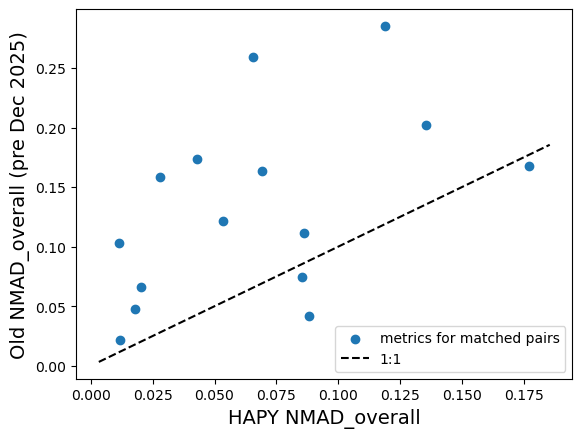

In [75]:
plt.figure()

x1 = new_common_stats["NMAD_overall"]
y1 = old_common_stats["NMAD_overall"]

plt.scatter(x1,y1, label="metrics for matched pairs")

xmin, xmax = plt.xlim()
xline = np.linspace(xmin,xmax,100)
plt.plot(xline,xline,'k--',label="1:1")

plt.xlabel("HAPY NMAD_overall", fontsize=14)
plt.ylabel("Old NMAD_overall (pre Dec 2025)", fontsize=14)
plt.legend()

## Latex Paper

In [87]:
import numpy as np
import pandas as pd

SUMMARY_METRICS = [
    ("R50_ARCSEC", "arcsec", r"$R_{50}(r)$"),
    ("R75_ARCSEC", "arcsec", r"$R_{75}(r)$"),
    ("R24_FLUX_CGS", "cgs", r"$F_r(R_{24})$"),
    ("R_C30", "value", r"$C_{30}(r)$"),

    ("H50_ARCSEC", "arcsec", r"$R_{50}(\mathrm{H}\alpha)$"),
    ("H75_ARCSEC", "arcsec", r"$R_{75}(\mathrm{H}\alpha)$"),
    ("CSGR_H_R24_FLUX_CGS", "cgs", r"$F_{\mathrm{H}\alpha}(R_{24})$"),
    ("CSGR_H_ISO17E18_ARCSEC", "arcsec", r"$R_{\mathrm{iso}}(\mathrm{H}\alpha)$"),
    ("CSGR_H_C30_R24", "value", r"$C_{30}(\mathrm{H}\alpha)$"),
]


def make_catalog_summary_table(tab, metrics=SUMMARY_METRICS):
    rows = []

    for col, unit, label in metrics:
        if col not in tab.colnames:
            print(f"WARNING: missing column {col}")
            continue

        x = np.asarray(tab[col], dtype=float)
        good = np.isfinite(x)

        # for fluxes, summarize log10 values
        if "FLUX" in col:
            good &= x > 0
            vals = np.log10(x[good])
            out_unit = "log cgs"
            stat_label = r"$\log_{10}$"
        else:
            vals = x[good]
            out_unit = unit
            stat_label = ""

        if len(vals) == 0:
            rows.append({
                "Quantity": label,
                "Column": col,
                "Unit": out_unit,
                "N": 0,
                "Median": np.nan,
                "P16": np.nan,
                "P84": np.nan,
                "P05": np.nan,
                "P95": np.nan,
            })
            continue

        p05, p16, p50, p84, p95 = np.nanpercentile(vals, [5, 16, 50, 84, 95])

        rows.append({
            "Quantity": label,
            "Column": col,
            "Unit": out_unit,
            "N": int(len(vals)),
            "Median": p50,
            "P16": p16,
            "P84": p84,
            "P05": p05,
            "P95": p95,
        })

    return pd.DataFrame(rows)


summary = make_catalog_summary_table(tab_fc)

summary

,Quantity,Column,Unit,N,Median,P16,P84,P05,P95
0,$R_{50}(r)$,R50_ARCSEC,arcsec,642,10.909982,5.778890,26.883416,4.177067,40.614586
1,$R_{75}(r)$,R75_ARCSEC,arcsec,642,17.723082,9.546338,44.421789,6.742813,68.503498
2,$F_r(R_{24})$,R24_FLUX_CGS,log cgs,632,-11.505825,-12.470369,-10.452452,-12.761344,-9.942982
3,$C_{30}(r)$,R_C30,value,631,0.310819,0.202314,0.486014,0.171721,0.587678
4,$R_{50}(\mathrm{H}\alpha)$,H50_ARCSEC,arcsec,533,11.571900,3.990589,30.599116,2.102201,58.929815
5,$R_{75}(\mathrm{H}\alpha)$,H75_ARCSEC,arcsec,533,18.628038,6.009474,48.472772,3.385500,86.966726
6,$F_{\mathrm{H}\alpha}(R_{24})$,CSGR_H_R24_FLUX_CGS,log cgs,537,-13.232288,-14.264122,-12.390249,-14.778390,-11.914119
7,$R_{\mathrm{iso}}(\mathrm{H}\alpha)$,CSGR_H_ISO17E18_ARCSEC,arcsec,545,20.259420,7.457845,50.540274,4.118754,79.907136
8,$C_{30}(\mathrm{H}\alpha)$,CSGR_H_C30_R24,value,538,0.397548,0.161020,0.694082,0.078212,0.825252


In [88]:
newtab

VFID,GALNAME,OBJID,RA,DEC,REDSHIFT,VR,HAPY_VERSION,RUN_DATE,TELESCOPE,DATEOBS,POINTING,SCHEME,PARENT_RIMAGE,PARENT_HIMAGE,HFILTER,PIXSCALE,TAG,CUTDIR,MASK_FITS,MASK_SOURCE,PSF_FITS,R_FITS,CS_FITS,RFILTER_FILENAME,RFILTER_CENTER,RFILTER_WIDTH,HFILTER_FILENAME,HFILTER_CENTER,HFILTER_WIDTH,PSF_SOURCE,STAGE,STATUS,MASK_SEC,PHOT_SEC,CSGR_SEC,SM_SEC,GAL_NC_SEC,GAL_CV_SEC,TOTAL_SEC,PSF_OK,MASK_OK,PHOT_OK,HAPY_MORPH_OK,R_PROFILE_OK,H_PROFILE_OK,R_SM_OK,H_SM_OK,GAL_NC_OK,GAL_CV_OK,GAL_CV_INIT_FROM_NC,GAL_NC_RERUN_FIXEDN,GAL_CV_RERUN_FIXEDN,ELL_MISMATCH,R_PETRO_OK,R_EXPFIT_OK,R_LOGFIT_OK,H_PETRO_OK,H_EXPFIT_OK,H_LOGFIT_OK,BRIGHT_STAR_FLAG,BRIGHT_STAR_DIST_ARCSEC,BRIGHT_STAR_MASKRAD_ARCSEC,BRIGHT_STAR_MAG,ELL0_MASKFRAC,ELL0_MASK_WARN,ELL0_NMASKPIX,ELL0_NTOTPIX,CUTOUT_SCALE,CUTOUT_XSIZE,CUTOUT_YSIZE,FILTER_CORRECTION,FILTER_RATIO,ELL0_SMA_ARCSEC,ELL0_BA,ELL0_PA_DEG,ELL0_XC,ELL0_YC,ELL0_SOURCE,CUTOUT_ELL0_MISSING_FRAC_R,CUTOUT_ELL0_MISSING_FRAC_H,CUTOUT_ELL0_MISSING_FRAC_MAX,CUTOUT_ELL0_NPIX_TOTAL_R,CUTOUT_ELL0_NPIX_TOTAL_H,CUTOUT_ELL0_NPIX_ONIMAGE_R,CUTOUT_ELL0_NPIX_ONIMAGE_H,CUTOUT_ELL0_NPIX_GOOD_R,CUTOUT_ELL0_NPIX_GOOD_H,ELLIP_XCENTROID,ELLIP_YCENTROID,ELLIP_SMA_PIX,ELLIP_SMA_ARCSEC,ELLIP_BA,ELLIP_B_ARCSEC,ELLIP_EPS,ELLIP_THETA_RAD,ELLIP_PA_DEG,R_ELLIP_GINI,H_ELLIP_GINI,ELLIP_SOURCE_SUM,ELLIP_SEGMENT_FLUX,ELLIP_SEGMENT_MAG,ELLIP_CENTER_METHOD,AREA_GUESS_ELLIPSE_PIX,AREA_GUESS_ELLIPSE_UNMASKED_PIX,MASKFRAC_GUESS_ELLIPSE,R_FWHM_PSF,R_FWHM_SE,R_SKYSTD_ADU,R_SKYMED_ADU,R_SKYSTD_PHYS,R_M20,R_ASYM,R_ASYM_ERR,H_FWHM_PSF,H_FWHM_SE,H_SKYSTD_ADU,H_SKYMED_ADU,H_SKYSTD_PHYS,H_M20,H_ASYM,H_ASYM_ERR,R_SCALE_ADU_CGS,H_SCALE_ADU_CGS,R_HAPY_NPIX,H_HAPY_NPIX,H_HAPY_FILLFRAC,R_HAPY_SNP_ALL,H_HAPY_SNP_ALL,H_HAPY_SNP_DET,H_GINI_THRESHOLD,R_HAPY_XC,R_HAPY_YC,R_HAPY_GINI,H_HAPY_GINI,R_HAPY_M20,H_HAPY_M20,R_HAPY_ASYM,H_HAPY_ASYM,R_HAPY_ASYM_ERR,H_HAPY_ASYM_ERR,R_HAPY_ASYM_XC,R_HAPY_ASYM_YC,R_HAPY_MTOT,H_HAPY_MTOT,R_HAPY_M20SUM,H_HAPY_M20SUM,H_HAPY_FLUX_SEG,H_HAPY_MTOT2,H_HAPY_RMOM_ARCSEC,R_HAPY_FLUX_SEG,R_HAPY_MTOT2,R_HAPY_RMOM_ARCSEC,HAPY_MORPH_FLAG,ELL_DC_PX,ELL_DBA,ELL_DPA_DEG,ELL_SMA_RATIO,R_SM_FLAG,R_SM_XCENTROID,R_SM_YCENTROID,R_SM_GINI,R_SM_M20,R_SM_C,R_SM_A,R_SM_S,R_SM_RPETRO_ELLIP_ARCSEC,R_SM_RHALF_ELLIP_ARCSEC,R_SM_R20_ARCSEC,R_SM_R50_ARCSEC,R_SM_R80_ARCSEC,R_SM_RMAX_CIRCLE_ARCSEC,R_SM_RMAX_ELLIP_ARCSEC,R_SM_SERSIC_AMP,R_SM_SERSIC_RHALF_ARCSEC,R_SM_SERSIC_N,R_SM_SERSIC_XC,R_SM_SERSIC_YC,R_SM_SERSIC_ELLIP,R_SM_SERSIC_THETA,R_SM_SERSIC_CHISQ_DOF,R_SM_SERSIC_FLAG,R_SM_SN_PER_PIXEL,R_SM_SKY_MEAN,R_SM_SKY_MEDIAN,R_SM_SKY_SIGMA,H_SM_FLAG,H_SM_XCENTROID,H_SM_YCENTROID,H_SM_GINI,H_SM_M20,H_SM_C,H_SM_A,H_SM_S,H_SM_RPETRO_ELLIP_ARCSEC,H_SM_RHALF_ELLIP_ARCSEC,H_SM_R20_ARCSEC,H_SM_R50_ARCSEC,H_SM_R80_ARCSEC,H_SM_RMAX_CIRCLE_ARCSEC,H_SM_RMAX_ELLIP_ARCSEC,H_SM_SERSIC_AMP,H_SM_SERSIC_RHALF_ARCSEC,H_SM_SERSIC_N,H_SM_SERSIC_XC,H_SM_SERSIC_YC,H_SM_SERSIC_ELLIP,H_SM_SERSIC_THETA,H_SM_SERSIC_CHISQ_DOF,H_SM_SERSIC_FLAG,H_SM_SN_PER_PIXEL,H_SM_SKY_MEAN,H_SM_SKY_MEDIAN,H_SM_SKY_SIGMA,R_PROFILE_NGOOD,R_PROFILE_MASKFRAC_MAX,R25_ARCSEC,R25_PIX,R50_ARCSEC,R50_PIX,R75_ARCSEC,R75_PIX,R24_ARCSEC,R24_ARCSEC_ERR,R24_MAG,R24_MAG_ERR,R25_ISO_ARCSEC,R25_ISO_ARCSEC_ERR,R25_ISO_MAG,R25_ISO_MAG_ERR,R25P5_ARCSEC,R25P5_ARCSEC_ERR,R25P5_MAG,R25P5_MAG_ERR,R24_VEGA_ARCSEC,R24_VEGA_ARCSEC_ERR,R24_VEGA_MAG,R24_VEGA_MAG_ERR,R25_VEGA_ARCSEC,R25_VEGA_ARCSEC_ERR,R25_VEGA_MAG,R25_VEGA_MAG_ERR,R30R24_FLUX_CGS,R30R24_FLUX_CGS_ERR,R24_FLUX_CGS,R24_FLUX_CGS_ERR,R_C30,R_C30_ERR,R_PETRO_RAD_ARCSEC,R_PETRO_FLUX,R_PETRO_FLUX_CGS,R_PETRO_FLUX_CGS_ERR,R_PETRO_MAG,R_PETRO_R50_ARCSEC,R_PETRO_R90_ARCSEC,R_PETRO_CON,R_EXPFIT_I0,R_EXPFIT_K,R_EXPFIT_RE_ARCSEC,R_LOGFIT_SLOPE,R_LOGFIT_INTERCEPT,R_LOGFIT_RE_ARCSEC,R_TOT_MAG_SNR,R_TOT_FLUX_CGS_SNR,R_TOT_FLUX_CGS_SNR_ERR,R_SNR_TRUNC_ARCSEC,R_PROFILE_PEAK_BIN,R_PROFILE_PEAK_SMA,R_PROFILE_NONCENTRAL_PEAK,H_PROFILE_NGOOD,H_PROFILE_LONGRUN,H_NDET_RUNS,H_PROFILE_MASKFRAC_MAX,H_MAXDET_ARCSEC,H_MAXDET_PIX,H_TOT_FLUX_CGS,H_TOT_FLUX_CGS_ERR,H_SNR_TRUNC_ARCSEC,H25_ARCSEC,H25_PIX,H

,Quantity,Unit,$N_{\rm pair}$,Median offset,Overall NMAD,BOK--BOK NMAD,INT--INT NMAD,HDI--HDI NMAD,Cross-inst. NMAD
0,$R_{50}(r)$,dex,113,0.000671,0.018582,0.007377,0.012101,0.011546,0.022365
1,$R_{75}(r)$,dex,113,-0.001133,0.020120,0.011085,0.011539,0.011532,0.025450
2,$C_{30}(r)$,value,112,-0.001074,0.012093,0.006556,0.003487,0.004573,0.011831
3,$R_{50}(\mathrm{H}\alpha)$,dex,67,-0.003015,0.095851,0.007531,0.152163,0.197921,0.115281
4,$R_{75}(\mathrm{H}\alpha)$,dex,67,-0.007338,0.143363,0.009734,0.201332,0.267571,0.084295
5,$R_{\mathrm{iso}}(\mathrm{H}\alpha)$,dex,75,0.001283,0.051744,0.025710,0.103037,0.043394,0.067426
6,$C_{30}(\mathrm{H}\alpha)$,value,75,-0.020912,0.058681,0.025672,0.181382,0.084451,0.046917


# Comparing all duplicates with VFS Tables

In [354]:
def KE_SFR(haflux, redshift):
    from astropy.cosmology import WMAP9 as cosmo
    # SFR conversion from Kennicutt and Evans (2012)
    # log (dM/dt/Msun/yr) = log(Lx) - logCx
    logCx = 41.27
    #print(len(self.hafit.total_flux),len(self.gzdist))
    L = haflux*(4.*np.pi*cosmo.luminosity_distance(redshift).cgs.value**2)
    #print(L)
    detect_flag = L > 0
    sfr = np.zeros(len(L),'d')
    sfr[detect_flag] = np.log10(L[detect_flag]) - logCx
    return sfr

In [355]:
%run ~/github/Virgo/programs/readtablesv2.py
ssfr = v.cigale['bayes.sfh.sfr'] / v.cigale['bayes.stellar.m_star']

logsfr = np.log10(v.cigale['bayes.sfh.sfr'])
logmstar = np.log10(v.cigale['bayes.stellar.m_star'])
logssfr = logsfr - logmstar


table directory =  /Users/rfinn/research/Virgo/tables-north/v2/


In [356]:
mergedtab = os.path.join(working_dir,'tables/merged_results_virgo_20260514.fits')
%run ~/github/hapypost/hapypost/validate_duplicates.py $mergedtab --scheme virgo

Read 782 rows from /Users/rfinn/research/Virgo/hapypost/tables/merged_results_virgo_20260514.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 65, 'low': 283, 'medium': 434}
ELL_MISMATCH 235
FILTER_WARNING 75
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 281
length of table after applying CLEAN flag = 706
Observation multiplicity (N_obs : N_galaxies)
1: 468
2: 92
3: 18
Found 146 duplicate pairs


['BOK', 'INT', 'HDI', 'MOS']
med offset = 0.27233418813304666


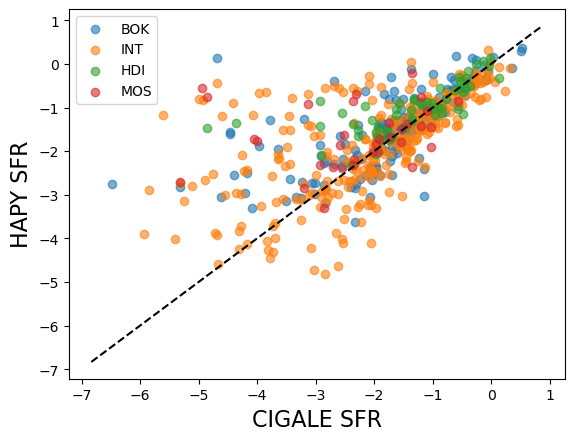

In [305]:
tels = set(tab['TELESCOPE'])
tels = ['BOK','INT','HDI','MOS']
print(tels)
#haflux = tab['H_TOT_FLUX_CGS']
haflux = tab["CSGR_H_ISO17E18_FLUX_CGS"]
haflux = tab["H_ISO17E18_FLUX_CGS"]
redshift = v.main['vr'][tab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


x = logsfr[tab['VFINDEX']]
y = hapy_sfr
for t in tels:
    flag = (tab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],y[flag],label=t,alpha=0.6)
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
#plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel("CIGALE SFR",fontsize=16)
plt.ylabel("HAPY SFR",fontsize=16)
x1, x2 = plt.xlim()
xline = np.linspace(x1,x2,100)
plt.plot(xline,xline,'k--')
print(f"med offset = {np.median(y[flag] - x[flag])}")

#plt.axis([-4,1,-4,1])

BOK: med offset = 0.07580962736874808
INT: med offset = -0.01587850187290496
HDI: med offset = 0.22799688969358034
MOS: med offset = 0.27233418813304666
number with offset > 2 = 41
VFID0481 4.826487576517631
VFID0481 4.245123234349502
VFID1275 3.3113241239196647
VFID1363 2.623983335015268
VFID1853 3.527513007121276
VFID2011 2.241617210118867
VFID2076 2.913212142769762
VFID2076 2.861064810930113
VFID2084 2.258384896948195
VFID2099 2.0678941856075874
VFID2114 4.192361926108957
VFID2221 2.1817038093388463
VFID2237 2.2208044309801833
VFID2239 2.177645831399416
VFID2487 2.0827049822338872
VFID2551 2.1167507338503553
VFID2840 2.9016160102286905
VFID2895 3.7378533081337695
VFID2963 4.444684223095535
VFID3037 2.0507575303238634
VFID3236 3.1964927156383043
VFID3357 3.384483608673855
VFID3454 2.2976944143512408
VFID3467 3.0258210333257898
VFID3500 2.296806794296531
VFID3516 2.3152530247771193
VFID4811 2.4954154179088497
VFID5917 3.400413194456167
VFID5943 4.098769108366884
VFID5972 2.04294218065

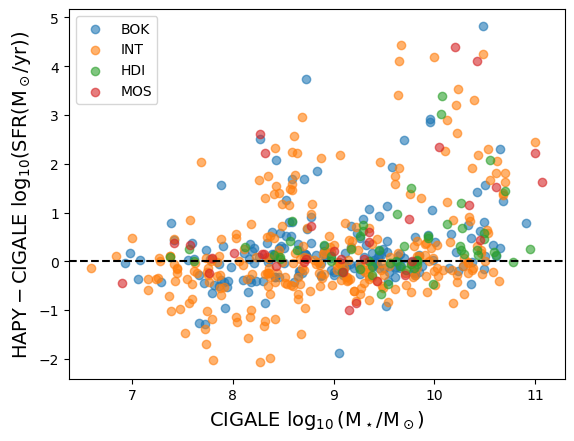

In [359]:
#tels = set(tab['TELESCOPE'])
#print(tels)
haflux = tab['CSGR_H_TOT_FLUX_CGS']
haflux = tab['H_ISO17E18_FLUX_CGS']
redshift = v.main['vr'][tab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


x = logsfr[tab['VFINDEX']]

y = hapy_sfr

delta = y - x
x = logmstar[tab['VFINDEX']]

for t in tels:
    flag = (tab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],delta[flag],label=t,alpha=0.6)
    print(f"{t}: med offset = {np.median(delta[flag])}")
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel(r"$\rm CIGALE \ \log_{10}(M_\star/M_\odot) $",fontsize=14)
plt.ylabel(r"$\rm HAPY - CIGALE \ log_{10}(SFR (M_\odot/yr))$",fontsize=14)

# print VFID of galaxies with delta > 2

outlier_flag = (delta > 2) & (haflux > 0) & np.isfinite(logmstar[tab['VFINDEX']]) & np.isfinite(logsfr[tab['VFINDEX']])
print(f"number with offset > 2 = {np.sum(outlier_flag)}")

for vf,d in zip(tab['VFID'][outlier_flag],delta[outlier_flag]): print(vf,d)

Text(0.5, 36.72222222222221, 'CIGALE SFR')

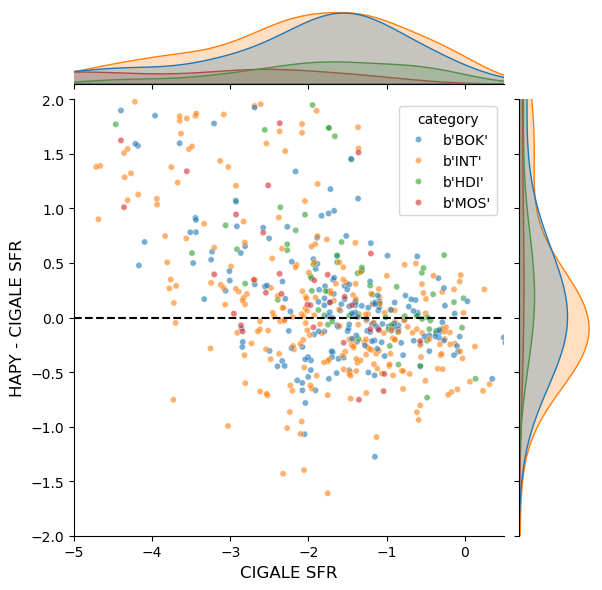

In [337]:

x = logsfr[tab['VFINDEX']]
y = hapy_sfr
g = plotting.jointplot_with_hue(x,y-x,tab['TELESCOPE'])
g.ax_joint.set_xlim(-5, .5)
g.ax_joint.set_ylim(-2, 2)
g.ax_joint.axhline(c='k',ls='--')

g.ax_joint.set_ylabel("HAPY - CIGALE SFR",fontsize=12)
g.ax_joint.set_xlabel("CIGALE SFR",fontsize=12)

med offset = -10.544996543096914


Text(0.5, 36.72222222222221, 'CIGALE SFR')

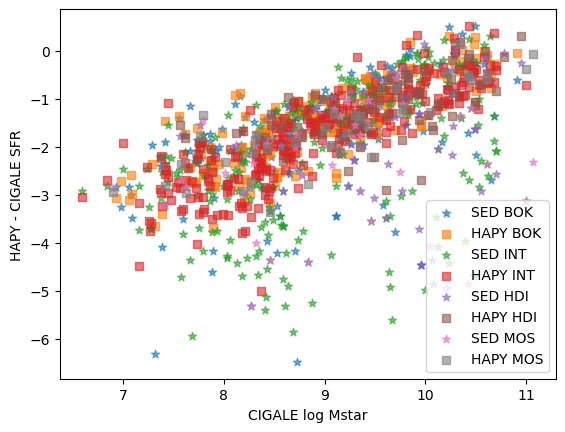

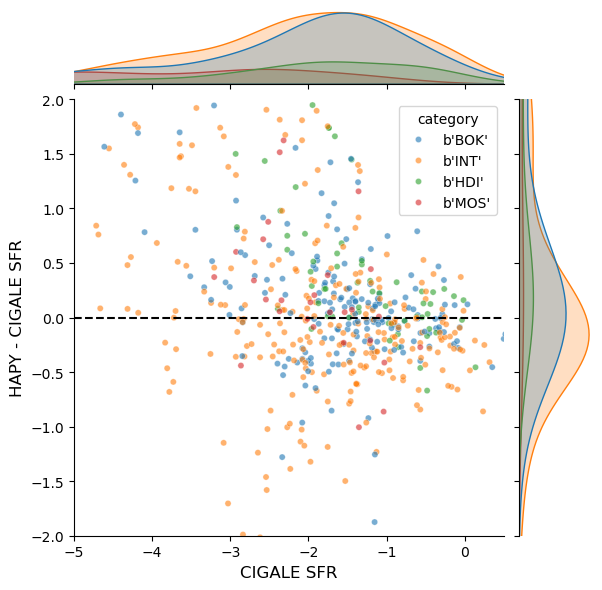

In [381]:
#tels = set(tab['TELESCOPE'])
#print(tels)
haflux = tab['CSGR_H_TOT_FLUX_CGS']
redshift = v.main['vr'][tab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


y1 = logsfr[tab['VFINDEX']]

y2 = hapy_sfr

delta = y2 - y1
x = logmstar[tab['VFINDEX']]

for t in tels:
    flag = (tab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],y1[flag],marker='*',label="SED "+t,alpha=0.6)
    plt.scatter(x[flag],y2[flag],marker='s',label="HAPY "+t,alpha=0.6)
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
#plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel("CIGALE log Mstar")
plt.ylabel("HAPY - CIGALE SFR")
print(f"med offset = {np.median(y[flag] - x[flag])}")

x = logsfr[tab['VFINDEX']]
g = plotting.jointplot_with_hue(x,y-x,tab['TELESCOPE'])
g.ax_joint.set_xlim(-5, .5)
g.ax_joint.set_ylim(-2, 2)
g.ax_joint.axhline(c='k',ls='--')

g.ax_joint.set_ylabel("HAPY - CIGALE SFR",fontsize=12)
g.ax_joint.set_xlabel("CIGALE SFR",fontsize=12)

med offset = -10.544996543096914


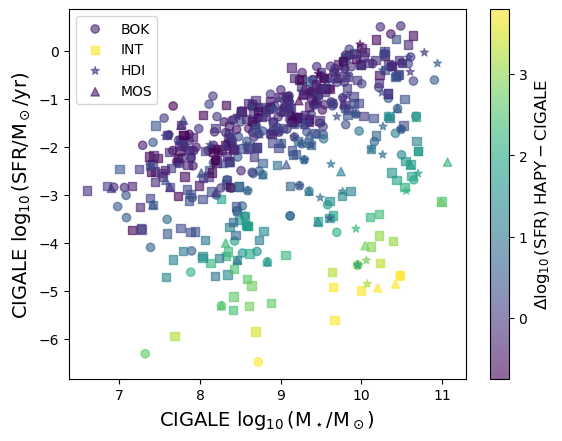

In [379]:
#tels = set(tab['TELESCOPE'])
#print(tels)
haflux = tab['CSGR_H_TOT_FLUX_CGS']
redshift = v.main['vr'][tab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


y1 = logsfr[tab['VFINDEX']]

y2 = hapy_sfr

delta = y2 - y1
x = logmstar[tab['VFINDEX']]
shapes=['o','s','*','^']
vmin=-.75
vmax=3.8
for i,t in enumerate(tels):
    flag = (tab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],y1[flag],marker=shapes[i],c=delta[flag], label=t,alpha=0.6,vmin=vmin,vmax=vmax)
cb = plt.colorbar()
cb.set_label(r"$\rm \Delta \log_{10}(SFR) \ HAPY-CIGALE $",size=12) 
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
#plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel(r"$\rm CIGALE \ \log_{10} (M_\star/M_\odot)$",fontsize=14)
plt.ylabel(r"$\rm CIGALE \ \log_{10}(SFR/M_\odot/yr)$",fontsize=14)
print(f"med offset = {np.median(y[flag] - x[flag])}")



# Comparing Best Duplicates with VFS Tables